Montar Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Definir rutas y cargar las tablas de Risaralda

In [ ]:
import pandas as pd

paths = {
    "PERSONAS": "/content/drive/MyDrive/PROYECTO GRADO FILES/Censo 2018 y Geografía/66/CNPV2018_5PER_A2_66.CSV",
    "HOGARES":  "/content/drive/MyDrive/PROYECTO GRADO FILES/Censo 2018 y Geografía/66/CNPV2018_2HOG_A2_66.CSV",
    "VIVIENDAS":"/content/drive/MyDrive/PROYECTO GRADO FILES/Censo 2018 y Geografía/66/CNPV2018_1VIV_A2_66.CSV",
    "FALLECIDOS":"/content/drive/MyDrive/PROYECTO GRADO FILES/Censo 2018 y Geografía/66/CNPV2018_3FALL_A2_66.CSV",
    "MGN":      "/content/drive/MyDrive/PROYECTO GRADO FILES/Censo 2018 y Geografía/66/CNPV2018_MGN_A2_66.CSV",
}

def read_df(path):
    # Misma lectura que usamos: CSV con coma y latin-1
    return pd.read_csv(path, sep=",", encoding="latin-1", low_memory=False)


Filtrar Pereira desde Risaralda
Qué hacemos: como el censo viene por departamento, primero cargamos todo Risaralda (66) y luego filtramos solo el municipio Pereira (001).

Por qué normalizamos (zfill): a veces los códigos vienen como 1 en vez de "001", entonces los “rellenamos” para que el filtro sea robusto.

In [ ]:
def filter_pereira(df):
    dpto = df["U_DPTO"].astype(str).str.zfill(2)
    mpio = df["U_MPIO"].astype(str).str.zfill(3)
    return df[(dpto == "66") & (mpio == "001")].copy()

dfs_per = {}

for name, path in paths.items():
    df = read_df(path)
    df_per = filter_pereira(df)
    dfs_per[name] = df_per
    print(name, df.shape, "-> Pereira:", df_per.shape)


PERSONAS (839597, 48) -> Pereira: (409670, 48)
HOGARES (278133, 13) -> Pereira: (139050, 13)
VIVIENDAS (342396, 30) -> Pereira: (173564, 30)
FALLECIDOS (6243, 11) -> Pereira: (2931, 11)
MGN (342396, 14) -> Pereira: (173564, 14)


Normalizar llaves para que los merges no fallen

In [ ]:
def norm_keys(df):
    df["U_DPTO"] = df["U_DPTO"].astype(str).str.zfill(2)
    df["U_MPIO"] = df["U_MPIO"].astype(str).str.zfill(3)
    df["COD_ENCUESTAS"] = df["COD_ENCUESTAS"].astype(str)
    df["U_VIVIENDA"] = df["U_VIVIENDA"].astype(str)
    return df

for k in dfs_per:
    dfs_per[k] = norm_keys(dfs_per[k])


Consolidar: PERSONAS → HOGARES → VIVIENDAS → MGN


Qué hacemos: construimos una sola base maestra por persona, pegándole (en cascada) la info del hogar, la vivienda y la geografía.

In [ ]:
df_PH = dfs_per["PERSONAS"].merge(
    dfs_per["HOGARES"],
    left_on=["U_DPTO","U_MPIO","UA_CLASE","COD_ENCUESTAS","U_VIVIENDA","P_NROHOG"],
    right_on=["U_DPTO","U_MPIO","UA_CLASE","COD_ENCUESTAS","U_VIVIENDA","H_NROHOG"],
    how="left",
    suffixes=("", "_H")
)

df_PH.shape


(409670, 56)

In [ ]:
df_PHV = df_PH.merge(
    dfs_per["VIVIENDAS"],
    on=["U_DPTO","U_MPIO","UA_CLASE","COD_ENCUESTAS","U_VIVIENDA"],
    how="left",
    suffixes=("", "_V")
)

df_PHV.shape


(409670, 81)

In [ ]:
df_master = df_PHV.merge(
    dfs_per["MGN"],
    on=["U_DPTO","U_MPIO","UA_CLASE","COD_ENCUESTAS","U_VIVIENDA"],
    how="left"
)

df_master.shape


(409670, 90)

Chequeos rápidos de calidad

Columnas con demasiados nulos

In [ ]:
df_master.isna().mean().sort_values(ascending=False).head(15)


NameError: name 'df_master' is not defined

Seleccionar el núcleo analítico

In [ ]:
geo_cols = ["U_DPTO","U_MPIO","UA_CLASE","UA1_LOCALIDAD","U_SECT_URB","U_SECC_URB","U_MZA"]
demo_cols = ["P_SEXO","P_EDADR","P_PARENTESCOR"]
edu_cols = ["P_ALFABETA","PA_ASISTENCIA","P_NIVEL_ANOSR"]
salud_cols = ["P_ENFERMO","PA_LO_ATENDIERON","PA1_CALIDAD_SERV"]
trab_cols = ["P_TRABAJO"]
vivienda_cols = ["V_MAT_PARED","V_MAT_PISO","V_TIPO_VIV","V_CON_OCUP"]
serv_cols = ["VA_EE","VB_ACU","VC_ALC","VD_GAS","VE_RECBAS","VF_INTERNET"]
hacin_cols = ["H_NRO_CUARTOS","H_NRO_DORMIT","HA_TOT_PER"]
key_cols = ["U_VIVIENDA","P_NROHOG","P_NRO_PER"]

keep_cols = list(set(
    geo_cols + demo_cols + edu_cols + salud_cols +
    trab_cols + vivienda_cols + serv_cols + hacin_cols + key_cols
))

existing = set(df_master.columns)
kept = sorted(existing.intersection(keep_cols))
removed = sorted(existing - set(kept))

print("COLUMNAS QUE SE QUEDAN:", len(kept))
print("COLUMNAS ELIMINADAS:", len(removed))


COLUMNAS QUE SE QUEDAN: 33
COLUMNAS ELIMINADAS: 57


In [ ]:
import pandas as pd

df_report = pd.DataFrame({
    "columna": kept + removed,
    "estado": ["SE QUEDA"]*len(kept) + ["SE ELIMINA"]*len(removed)
})

df_report["bloque"] = df_report["columna"].map(
    lambda c:
        "Geografía" if c in geo_cols else
        "Demografía" if c in demo_cols else
        "Educación" if c in edu_cols else
        "Salud" if c in salud_cols else
        "Trabajo" if c in trab_cols else
        "Vivienda" if c in vivienda_cols else
        "Servicios" if c in serv_cols else
        "Hacinamiento" if c in hacin_cols else
        "Llaves" if c in key_cols else
        "Otros"
)

# 👇 Tablas separadas como la vez pasada
display(df_report[df_report.estado == "SE QUEDA"].sort_values(["bloque","columna"]))
display(df_report[df_report.estado == "SE ELIMINA"].sort_values(["bloque","columna"]))


,columna,estado,bloque
7,P_EDADR,SE QUEDA,Demografía
12,P_PARENTESCOR,SE QUEDA,Demografía
13,P_SEXO,SE QUEDA,Demografía
4,PA_ASISTENCIA,SE QUEDA,Educación
6,P_ALFABETA,SE QUEDA,Educación
9,P_NIVEL_ANOSR,SE QUEDA,Educación
15,UA1_LOCALIDAD,SE QUEDA,Geografía
16,UA_CLASE,SE QUEDA,Geografía
17,U_DPTO,SE QUEDA,Geografía
18,U_MPIO,SE QUEDA,Geografía


,columna,estado,bloque
33,COD_DANE_ANM,SE ELIMINA,Otros
34,COD_ENCUESTAS,SE ELIMINA,Otros
35,CONDICION_FISICA,SE ELIMINA,Otros
36,HA_NRO_FALL,SE ELIMINA,Otros
37,H_AGUA_COCIN,SE ELIMINA,Otros
38,H_DONDE_PREPALIM,SE ELIMINA,Otros
39,H_NROHOG,SE ELIMINA,Otros
40,L_EXISTEHOG,SE ELIMINA,Otros
41,L_TIPO_INST,SE ELIMINA,Otros
42,L_TOT_PERL,SE ELIMINA,Otros


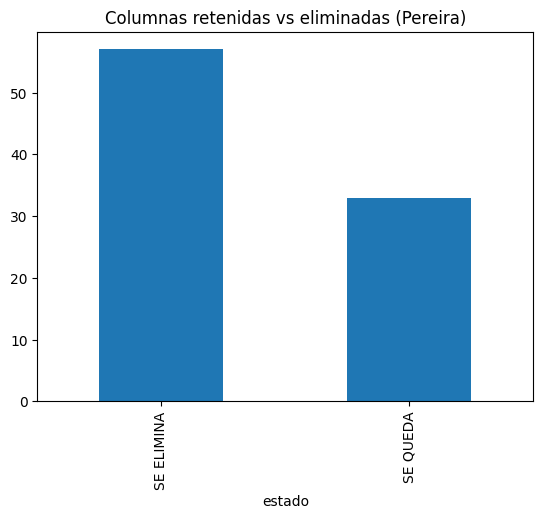

In [ ]:
import matplotlib.pyplot as plt

df_report["estado"].value_counts().plot(kind="bar")
plt.title("Columnas retenidas vs eliminadas (Pereira)")
plt.show()


Master reducido

In [ ]:
df_master_reducido = df_master.loc[:, kept].copy()

print("Original:", df_master.shape)
print("Reducido:", df_master_reducido.shape)


Original: (409670, 90)
Reducido: (409670, 33)


In [ ]:
output_path = "/content/drive/MyDrive/PROYECTO GRADO FILES/Censo 2018 y Geografía/pereira_base_consolidada_reducida.xlsx"
df_master_reducido.to_excel(output_path, index=False)
print("Archivo guardado en:", output_path)


Archivo guardado en: /content/drive/MyDrive/PROYECTO GRADO FILES/Censo 2018 y Geografía/pereira_base_consolidada_reducida.xlsx
